In [1]:
from analyzer_functions import *

## Full Interval

In [2]:
spin_path = 'data/ada-spin-100k.csv'
regs24_path = 'data/registers/ada-reg1108-24-100k.csv'
regs64_path = 'data/registers/ada-reg1108-64-100k.csv'
# regs64_path = 'data/regargs/ada-regargs-64-255-100k.csv'
regs128_path = 'data/registers/ada-reg1108-128-100k.csv'
regs192_path = 'data/registers/ada-reg1108-192-100k.csv'
regs255_path = 'data/registers/ada-reg1108-255-100k.csv'
# regs255_path = 'data/spinregs/ada-spinargs-255-100k.csv'

spin_ivls = read_ivls(spin_path, single=True)
regs24_ivls = read_ivls(regs24_path, single=True)
regs64_ivls = read_ivls(regs128_path, single=True)
regs128_ivls = read_ivls(regs128_path, single=True)
regs192_ivls = read_ivls(regs192_path, single=True)
regs255_ivls = read_ivls(regs255_path, single=True)

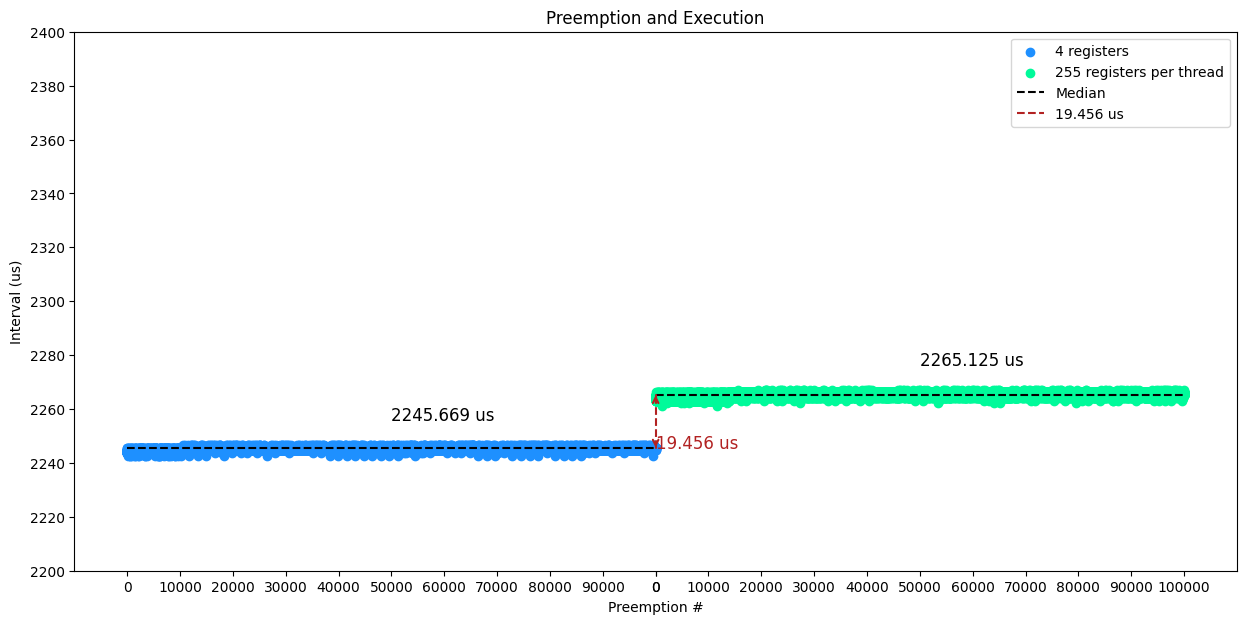

In [3]:
N = 100000
plot_side_by_side(noSharedData=spin_ivls, sharedData=regs255_ivls, NUM_SAMPLES=N, lowerBound=2200, upperBound=2400,
 				  firstLabel='4 registers', secondLabel='255 registers per thread', medianLines=True)

## Context Switch Overhead (single-side)

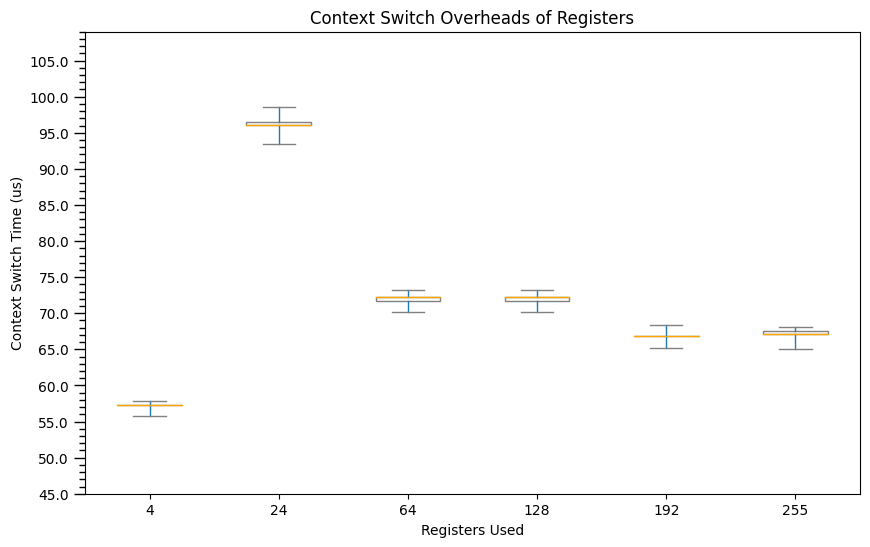

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TIMESLICE = 2131
spin_oh = get_overhead(spin_ivls, TIMESLICE)
regs24_oh = get_overhead(regs24_ivls, TIMESLICE)
regs64_oh = get_overhead(regs64_ivls, TIMESLICE)
regs128_oh = get_overhead(regs128_ivls, TIMESLICE)
regs192_oh = get_overhead(regs192_ivls, TIMESLICE)
regs255_oh = get_overhead(regs255_ivls, TIMESLICE)


data = {
	'4': spin_oh,
	'24': regs24_oh,
	'64': regs64_oh,
	'128': regs128_oh,
	'192': regs192_oh,
	'255': regs255_oh
}

# Convert the list of NumPy arrays to a DataFrame
df = pd.DataFrame(data)

# Create a boxplot
plt.figure(figsize=(10, 6))
df.boxplot(grid=False, 
           patch_artist=True,
           boxprops=dict(facecolor='none', color='gray'),
           flierprops=dict(markerfacecolor='red', marker='o', markersize=5),
           medianprops=dict(color='orange', linewidth=1),
		   capprops=dict(color='gray', linewidth=1),
		   whis=[0,100])

# Customize the plot
plt.title('Context Switch Overheads of Registers')
plt.xlabel('Registers Used')
plt.ylabel('Context Switch Time (us)')

# y ticks
ymin = np.floor(df.min().min()) - 10
ymax = np.ceil(df.max().max()) + 10
plt.ylim(ymin, ymax)
plt.yticks(np.arange(ymin, ymax, 1))
LABEL_STEP = 5
plt.gca().set_yticks(np.arange(ymin, ymax, LABEL_STEP).tolist())
plt.gca().set_yticklabels(np.arange(ymin, ymax, LABEL_STEP).tolist())

# Show minor ticks (for tick marks every 1 unit)
plt.gca().tick_params(axis='y', which='both', length=8, width=1)

# Show minor ticks and adjust their appearance
plt.gca().tick_params(axis='y', which='minor', length=4, width=1)

# Add minor ticks at every unit
plt.gca().minorticks_on()

# Disable minor ticks on the x-axis
plt.gca().tick_params(axis='x', which='minor', length=0)

# Show the plot
plt.show()

In [5]:
medians = {
	'4': [np.median(spin_oh)],
	'24': [np.median(regs24_oh)],
	'64': [np.median(regs64_oh)],
	'128': [np.median(regs128_oh)],
	'192': [np.median(regs192_oh)],
	'255': [np.median(regs255_oh)]
}

In [6]:
medians = pd.DataFrame(medians)

In [7]:
medians

,4,24,64,128,192,255
0,57.3345,96.022,72.1835,72.1835,66.781,67.0625


In [8]:
ymin

45.0

In [9]:
np.min(regs255_oh)

65.0139999999999